#Income Prediction using ML and Deap Learning

In [71]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler # for standard scalling, it is only work on numeric values


In [72]:
df = pd.read_csv('/content/adult.csv')

In [73]:
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


In [74]:
df.tail()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32560,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K


In [75]:
df.describe()

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
count,32561.000000,3.256100e+04,32561.000000,32561.000000,32561.000000,32561.000000
mean,38.581647,1.897784e+05,10.080679,1077.648844,87.303830,40.437456
std,13.640433,1.055500e+05,2.572720,7385.292085,402.960219,12.347429
min,17.000000,1.228500e+04,1.000000,0.000000,0.000000,1.000000
25%,28.000000,1.178270e+05,9.000000,0.000000,0.000000,40.000000
50%,37.000000,1.783560e+05,10.000000,0.000000,0.000000,40.000000
75%,48.000000,2.370510e+05,12.000000,0.000000,0.000000,45.000000
max,90.000000,1.484705e+06,16.000000,99999.000000,4356.000000,99.000000


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [77]:
df.isnull().sum()

,0
age,0
workclass,0
fnlwgt,0
education,0
education.num,0
marital.status,0
occupation,0
relationship,0
race,0
sex,0


In [78]:
df.nunique()

,0
age,73
workclass,9
fnlwgt,21648
education,16
education.num,16
marital.status,7
occupation,15
relationship,6
race,5
sex,2


In [79]:
df.shape

(32561, 15)

In [80]:
df.index

RangeIndex(start=0, stop=32561, step=1)

In [81]:
df.size

488415

In [82]:
df.dtypes

,0
age,int64
workclass,object
fnlwgt,int64
education,object
education.num,int64
marital.status,object
occupation,object
relationship,object
race,object
sex,object


<Axes: xlabel='age', ylabel='Count'>

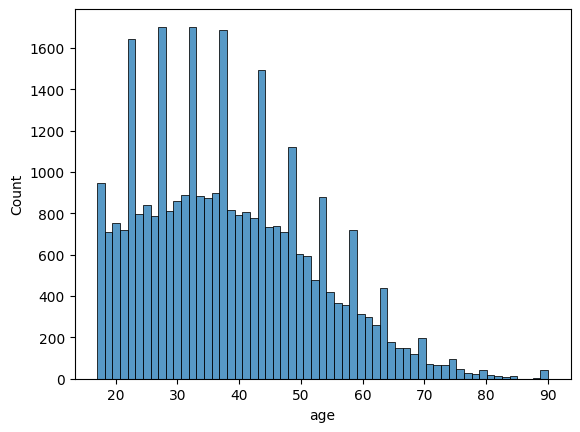

In [83]:
sns.histplot(df['age'])

<Axes: xlabel='income', ylabel='Count'>

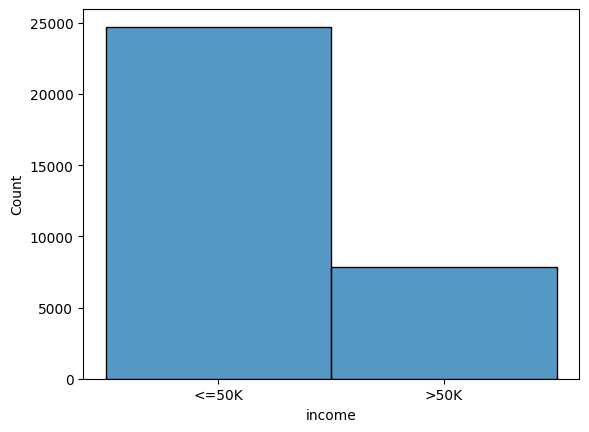

In [84]:
sns.histplot(df['income'])

<Axes: xlabel='count', ylabel='income'>

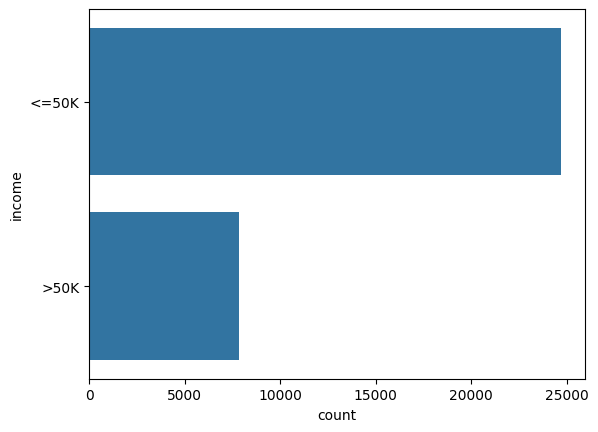

In [85]:
sns.countplot(df['income'])

<Axes: xlabel='count', ylabel='sex'>

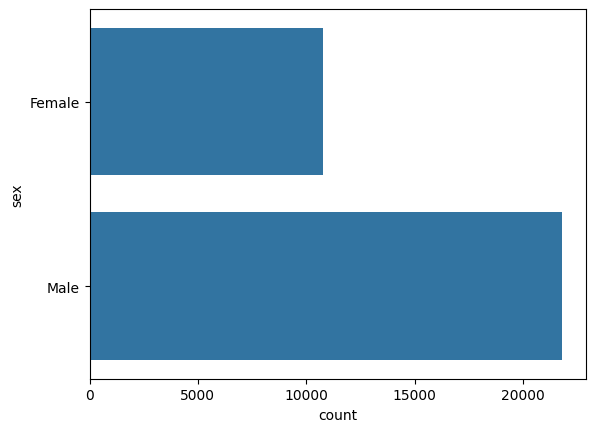

In [86]:
sns.countplot(df['sex'])

<Axes: xlabel='sex', ylabel='income'>

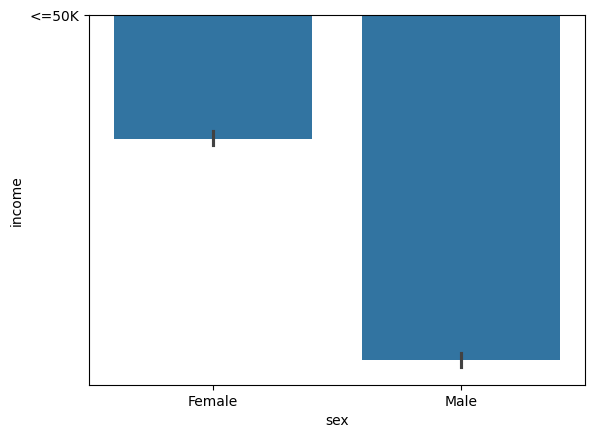

In [87]:
sns.barplot(data=df,x='sex',y='income')

In [88]:
label_df = df['sex'].value_counts().index

In [89]:
value_df = df['sex'].value_counts().values

([<matplotlib.patches.Wedge at 0x7ed7d2feac50>,
 [Text(-0.5575806930085762, 0.948210826126804, 'Male'),
  Text(0.5575805498327184, -0.9482109103191355, 'Female')],
 [Text(-0.3041349234592233, 0.5172059051600748, '66.92%'),
  Text(0.30413484536330093, -0.5172059510831648, '33.08%')])

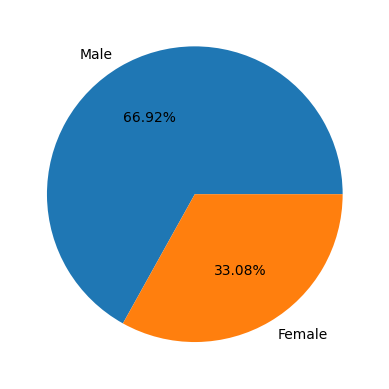

In [90]:
plt.pie(value_df,labels=label_df,autopct='%1.2f%%')

In [91]:
df.corr(numeric_only=True)

,age,fnlwgt,education.num,capital.gain,capital.loss,hours.per.week
age,1.000000,-0.076646,0.036527,0.077674,0.057775,0.068756
fnlwgt,-0.076646,1.000000,-0.043195,0.000432,-0.010252,-0.018768
education.num,0.036527,-0.043195,1.000000,0.122630,0.079923,0.148123
capital.gain,0.077674,0.000432,0.122630,1.000000,-0.031615,0.078409
capital.loss,0.057775,-0.010252,0.079923,-0.031615,1.000000,0.054256
hours.per.week,0.068756,-0.018768,0.148123,0.078409,0.054256,1.000000


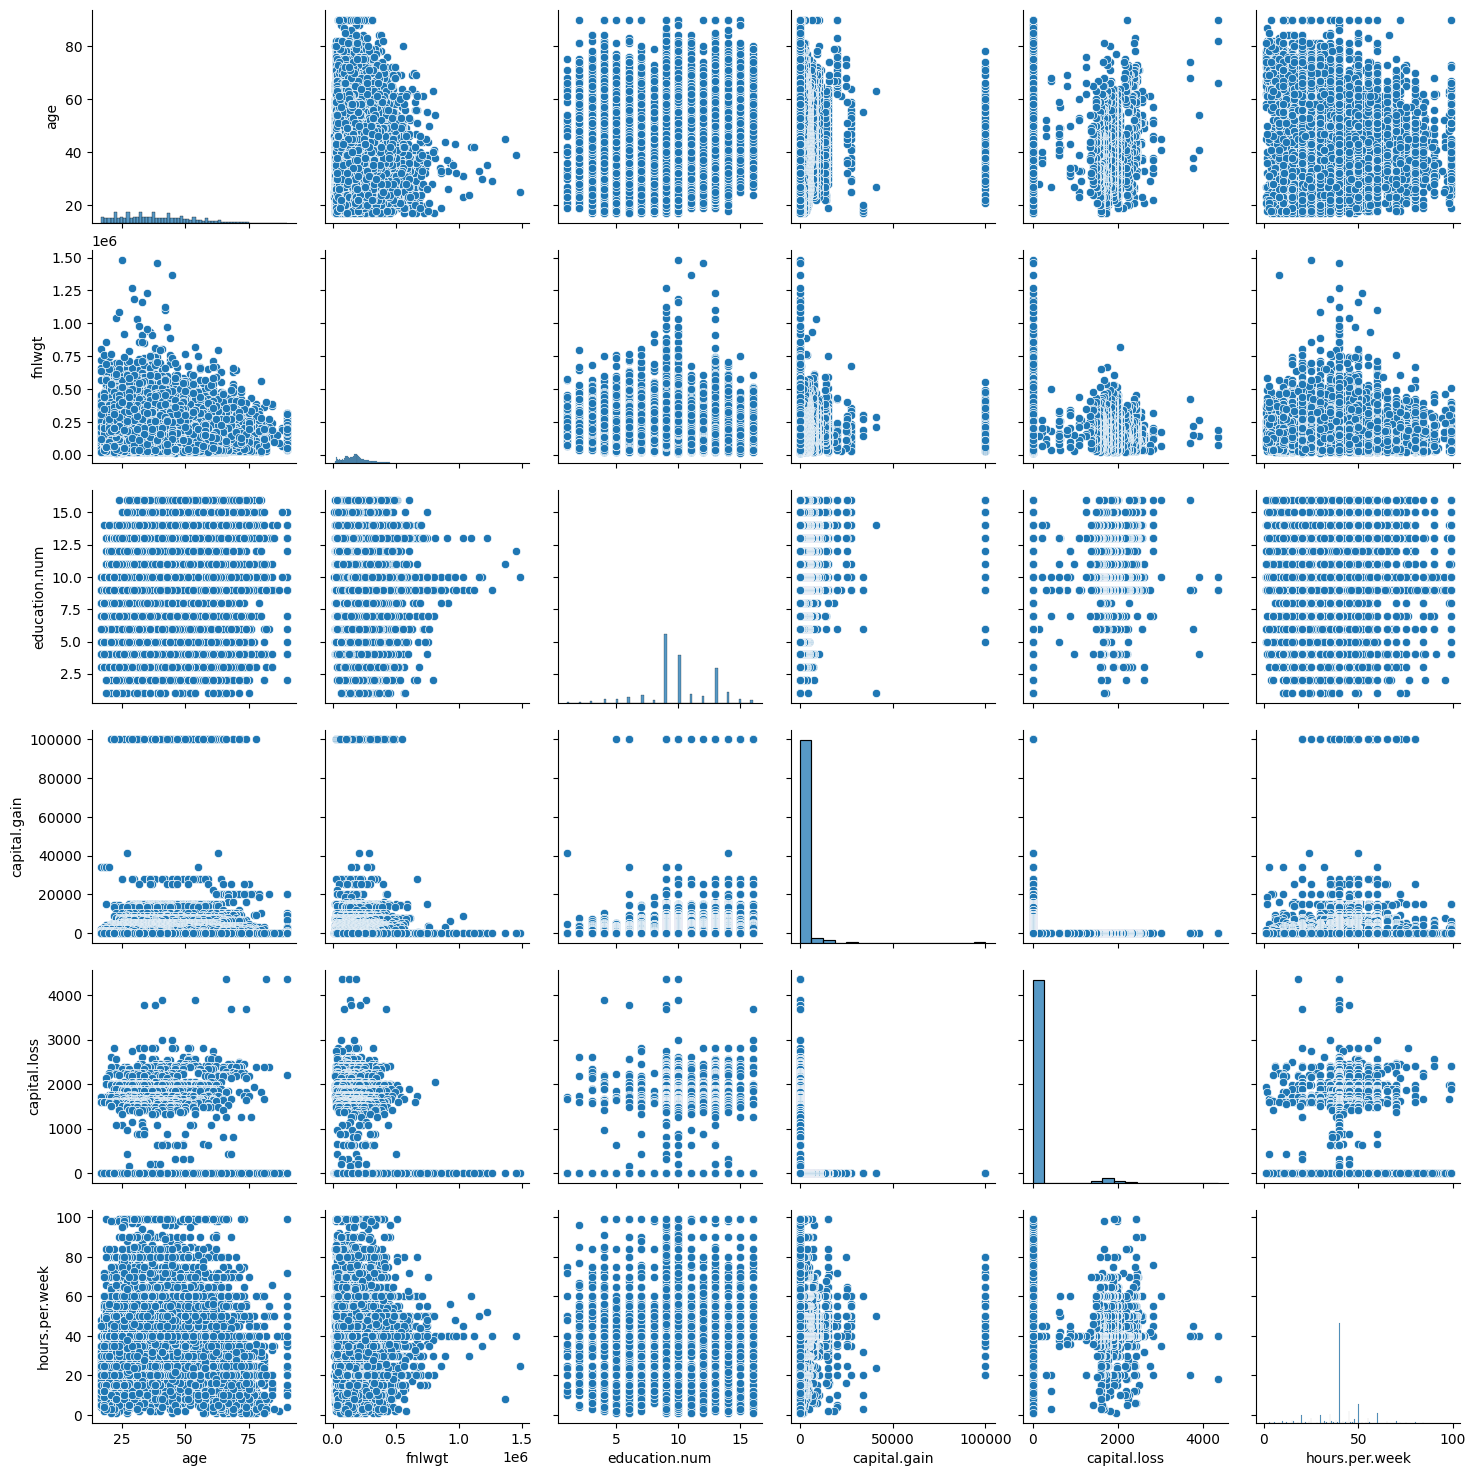

In [92]:
sns.pairplot(df)

In [93]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [94]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [95]:
df['workclass'] = le.fit_transform(df['workclass'])
df['education'] = le.fit_transform(df['education'])
df['marital.status'] = le.fit_transform(df['marital.status'])
df['occupation'] = le.fit_transform(df['occupation'])
df['relationship'] = le.fit_transform(df['relationship'])
df['race'] = le.fit_transform(df['race'])
df['sex'] = le.fit_transform(df['sex'])
df['native.country'] = le.fit_transform(df['native.country'])
df['income'] = le.fit_transform(df['income'])

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       32561 non-null  int64
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  int64
 4   education.num   32561 non-null  int64
 5   marital.status  32561 non-null  int64
 6   occupation      32561 non-null  int64
 7   relationship    32561 non-null  int64
 8   race            32561 non-null  int64
 9   sex             32561 non-null  int64
 10  capital.gain    32561 non-null  int64
 11  capital.loss    32561 non-null  int64
 12  hours.per.week  32561 non-null  int64
 13  native.country  32561 non-null  int64
 14  income          32561 non-null  int64
dtypes: int64(15)
memory usage: 3.7 MB


In [97]:
X = df.drop('income',axis=1)
y = df['income']

In [98]:
X

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country
0,90,0,77053,11,9,6,0,1,4,0,0,4356,40,39
1,82,4,132870,11,9,6,4,1,4,0,0,4356,18,39
2,66,0,186061,15,10,6,0,4,2,0,0,4356,40,39
3,54,4,140359,5,4,0,7,4,4,0,0,3900,40,39
4,41,4,264663,15,10,5,10,3,4,0,0,3900,40,39
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,4,310152,15,10,4,11,1,4,1,0,0,40,39
32557,27,4,257302,7,12,2,13,5,4,0,0,0,38,39
32558,40,4,154374,11,9,2,7,0,4,1,0,0,40,39
32559,58,4,151910,11,9,6,1,4,4,0,0,0,40,39


In [99]:
y

,income
0,0
1,0
2,0
3,0
4,0
...,...
32556,0
32557,0
32558,1
32559,0


In [100]:
df['income'].value_counts()

,count
income,
0,24720
1,7841


In [101]:
from imblearn.over_sampling import SMOTE     # we need to balance the data before Machine Learning

In [102]:
sm = SMOTE(random_state=42)

In [103]:
X_res, y_res = sm.fit_resample(X, y)

In [104]:
from sklearn.model_selection import train_test_split

In [105]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.33, random_state=42)

In [106]:
sc = StandardScaler()

In [107]:
X_train=sc.fit_transform(X_train)

In [108]:
X_test=sc.transform(X_test)

In [109]:
from sklearn.ensemble import RandomForestClassifier

In [110]:
rfc = RandomForestClassifier()

In [111]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [112]:
y_pred = rfc.predict(X_test)

In [113]:
y_pred

array([0, 0, 0, ..., 0, 1, 0])

In [114]:
from sklearn.metrics import accuracy_score

In [115]:
accuracy_score(y_test,y_pred)*100

89.32949252267713

In [116]:
from sklearn.neighbors import KNeighborsClassifier

In [117]:
knn = KNeighborsClassifier()

In [118]:
knn.fit(X_train,y_train)

KNeighborsClassifier()

In [119]:
y_pred = knn.predict(X_test)

In [120]:
y_pred

array([0, 0, 0, ..., 0, 1, 0])

In [121]:
accuracy_score(y_test,y_pred)*100

84.32213777886737

In [122]:
from sklearn.tree import DecisionTreeClassifier

In [123]:
dtc = DecisionTreeClassifier()

In [124]:
dtc.fit(X_train,y_train)

DecisionTreeClassifier()

In [125]:
y_pred = dtc.predict(X_test)

In [126]:
y_pred

array([0, 1, 0, ..., 0, 1, 0])

In [127]:
accuracy_score(y_test,y_pred)*100

85.5847021328757

In [128]:
from sklearn.linear_model import LogisticRegression

In [129]:
le = LogisticRegression()

In [130]:
le.fit(X_train,y_train)

LogisticRegression()

In [131]:
y_pred = le.predict(X_test)

In [132]:
y_pred

array([0, 1, 0, ..., 0, 1, 0])

In [133]:
accuracy_score(y_test,y_pred)*100

76.67320421671978

# Now we start PCA

In [134]:
#first we find information gain, and which give low info gain we drop it

In [135]:
from sklearn.decomposition import PCA

In [136]:
pca = PCA()

In [137]:
X_train = pca.fit_transform(X_train)
pca.explained_variance_ratio_

array([0.15339023, 0.09622186, 0.09073577, 0.08241084, 0.07579724,
       0.07479201, 0.06755161, 0.06486747, 0.06110481, 0.05924558,
       0.05564389, 0.04696263, 0.04462402, 0.02665204])

now elemenation the features which give less information


In [138]:
cumsum = np.cumsum(pca.explained_variance_ratio_)
dim = np.argmax(cumsum >= 0.90) + 1
print('The number of dimensions required to preserve 90% of variance is',dim)

The number of dimensions required to preserve 90% of variance is 12


In [139]:
df


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,0,77053,11,9,6,0,1,4,0,0,4356,40,39,0
1,82,4,132870,11,9,6,4,1,4,0,0,4356,18,39,0
2,66,0,186061,15,10,6,0,4,2,0,0,4356,40,39,0
3,54,4,140359,5,4,0,7,4,4,0,0,3900,40,39,0
4,41,4,264663,15,10,5,10,3,4,0,0,3900,40,39,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,4,310152,15,10,4,11,1,4,1,0,0,40,39,0
32557,27,4,257302,7,12,2,13,5,4,0,0,0,38,39,0
32558,40,4,154374,11,9,2,7,0,4,1,0,0,40,39,1
32559,58,4,151910,11,9,6,1,4,4,0,0,0,40,39,0


In [141]:
X=df.drop(['income','native.country','hours.per.week'],axis=1)
X = sc.fit_transform(X)
y=df['income']

In [142]:
sm = SMOTE(random_state=42)

In [143]:
X_res, y_res = sm.fit_resample(X, y)

In [144]:
X_train, X_test, y_train, y_test = train_test_split(
    X_res, y_res, test_size=0.33, random_state=42)

In [145]:
rfc = RandomForestClassifier()

In [146]:
rfc.fit(X_train,y_train)

RandomForestClassifier()

In [147]:
y_pred = rfc.predict(X_test)

In [148]:
y_pred

array([0, 0, 0, ..., 0, 1, 0])

In [149]:
accuracy_score(y_test,y_pred)*100

88.83917626869331

# Now Apply Deap Learning

In [150]:
pip install --upgrade keras

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 10.1 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 3.8.0
    Uninstalling keras-3.8.0:
      Successfully uninstalled keras-3.8.0


In [151]:
import keras
print(keras.__version__)

3.9.2


In [152]:
model = keras.Sequential()

In [153]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [154]:
model.add(
    keras.Input(
        shape=(12,),
        batch_size=32
    )
)

In [155]:
model.add(                                 #hidden layer
    keras.layers.Dense(
    64,
    activation='relu'
))

In [156]:
model.add(                      # hidden layer
    keras.layers.Dense(
    128,
    activation='relu'
))

In [157]:
model.add(                         ## Output layer
        keras.layers.Dense(
    1,
    activation='sigmoid'   # use when we check 1 and 0
)
)

In [158]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (32, 64)               │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (32, 128)              │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (32, 1)                │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,281 (36.25 KB)

 Trainable params: 9,281 (36.25 KB)

 Non-trainable params: 0 (0.00 B)

In [159]:
model.compile(
    optimizer="adam",
    loss='binary_crossentropy',
    metrics=['accuracy']
)


In [160]:
callback=keras.callbacks.EarlyStopping(
    monitor="val_accuracy",
    patience=3,
    verbose=0,
    restore_best_weights=True,
)              ## it will increase accuracy

In [161]:
model.fit(
    x=X_train,
    y=y_train,
    batch_size=32,
    epochs=100,
    verbose="auto",
    validation_data=(X_test,y_test),
    callbacks=[callback]
)

Epoch 1/100
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.7874 - loss: 0.4510 - val_accuracy: 0.8164 - val_loss: 0.3962
Epoch 2/100
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8205 - loss: 0.3849 - val_accuracy: 0.8193 - val_loss: 0.3891
Epoch 3/100
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8248 - loss: 0.3793 - val_accuracy: 0.8206 - val_loss: 0.3856
Epoch 4/100
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8268 - loss: 0.3733 - val_accuracy: 0.8207 - val_loss: 0.3841
Epoch 5/100
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - accuracy: 0.8294 - loss: 0.3658 - val_accuracy: 0.8242 - val_loss: 0.3807
Epoch 6/100
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8296 - loss: 0.3658 - val_accuracy: 0.8229 - val_loss: 0.3766
Epoch 7/100
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8368 - loss: 0.3537 - val_accuracy: 0.8230 - val_loss: 0.3800
Epoch 8/100
1036/1036 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8328 - loss: 0

In [162]:
model.evaluate(
    x=X_test,
    y=y_test,
    batch_size=32,
    verbose="auto",
)

510/510 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.8238 - loss: 0.3783


[0.3807299733161926, 0.8242216110229492]